This our second notebook for model training. We're taking everything from model1.ipynb and polishing it, while also adding some new features.

## Pre-processing

In [209]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

We'll load our TPM/CFU data as a dataframe, then view.

In [210]:
# Load all data
all_data_pre = pd.read_csv("all_model_data.csv")

# Move condition column to index
all_data_pre.rename(columns = {"Unnamed: 0": "Condition"}, inplace = True)
all_data_pre = all_data_pre.set_index("Condition")
all_data_pre.head(n = 5)

,SP_0001,SP_0002,SP_0003,SP_0004,SP_0005,SP_0006,SP_0007,SP_0008,SP_0009,SP_0010,...,SP_2231,SP_2233,SP_2234,SP_2235,SP_2236,SP_2237,SP_2238,SP_2239,SP_2240,CFU
Condition,,,,,,,,,,,,,,,,,,,,,
12AMX1hr-a,100.731718,62.523979,29.350576,136.628654,23.311941,18.360644,23.639356,54.915731,16.204642,49.999429,...,58.423669,5.190549,31.812428,12.352542,18.789319,0.000000,19.378051,1556.989150,2065.824961,1.380000e+09
12AMX1hr-b,110.761813,85.441234,30.011332,140.199108,12.290825,19.560271,10.495536,73.411867,11.391497,55.575063,...,49.943212,7.297677,28.384337,13.025337,23.951352,11.120270,13.622331,1560.789227,2192.495376,1.500000e+09
12AMX1hr-c,86.013352,62.605378,31.936738,128.435857,15.992967,18.401074,28.330836,63.601162,11.038218,47.381206,...,57.586997,5.050970,23.932111,11.333492,18.576600,24.629493,19.799804,1510.799073,1961.293782,1.440000e+09
12AMX2hr-a,58.112596,60.819299,42.382520,189.375150,24.848367,31.648666,49.926659,100.851174,27.094345,73.751491,...,50.583010,4.700939,18.412179,7.376283,13.194701,6.612310,21.985932,1074.685060,1070.619314,3.240000e+09
12AMX2hr-b,53.327570,56.106699,32.410598,193.525955,47.194380,29.561315,66.208488,138.513586,9.373100,74.497309,...,51.480457,5.504255,25.478260,10.717449,14.490841,0.000000,18.414236,1000.733037,996.438310,3.260000e+09


We'll check if any data has 0 CFU, which will mess our analysis up when we log-transform the CFUS.

In [211]:
print(np.where(all_data_pre["CFU"] == 0))
print(all_data_pre.index[all_data_pre["CFU"] == 0].tolist())

(array([404]),)
['34CEF4hr-c']


Let's log-transform our CFU values, then remove the row with $-\infty$ CFU, which corresponds to the row we identified above. We can also check the range of CFU values to make sure it's reasonable for our modeling purposes.

In [212]:
# Log-transform CFUs
all_data_log = all_data_pre.copy()
all_data_log["CFU"] = np.log(all_data_log["CFU"])

# Filter out column with 0 CFU since log is -inf
all_data_log.replace([-np.inf], np.nan, inplace=True)
all_data_log.dropna(inplace = True)

# Checking the range of the log rmalized CFUs, this looks fine
print(f"Log CFU min : {all_data_log["CFU"].min()}")
print(f"Log CFU max : {all_data_log["CFU"].max()}")
print(f"Log CFU mean: {all_data_log["CFU"].mean()} \n")

# Check dimensions of data
print(f"# training examples : {all_data_log.shape[0]}")
print(f"# genes/features    : {all_data_log.shape[1]}")

Log CFU min : 12.89921982609012
Log CFU max : 24.323314077353732
Log CFU mean: 19.35072249856656 

# training examples : 470
# genes/features    : 2192


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Let's also load our annotations so that we can use them later for interpretability.

In [213]:
# Read annotations
annotations = pd.read_csv("Annotation_TIGR4.tsv", sep = "\t")

# Set gene ID as index
annotations.set_index("TIGR4.old", inplace = True, drop = True)

# Dimensions
print(annotations.shape)
print(annotations.columns)
annotations.head(n = 5)

(1800, 30)
Index(['Cluster', 'Subcluster', 'Product', 'Strain', 'Genome', 'locus',
       'Start', 'End', 'Strand', 'Total.Insertions', 'Total.Sites', 'zbar',
       'Binomial.Call', 'HMM.Call', 'D39.old', 'TAIWAN.19F.new',
       'TAIWAN.19F.old', 'D39.new', 'GENE.DESCRIPTION', 'GENE.CATEGORY',
       'Location.Tag', 'Tag1', 'Tag2', 'Tag3', 'Category1', 'Category2',
       'Category3', 'No..of.Categories', 'Gene.Name',
       'GO.terms..biological.process.'],
      dtype='str')


,Cluster,Subcluster,Product,Strain,Genome,locus,Start,End,Strand,Total.Insertions,...,Location.Tag,Tag1,Tag2,Tag3,Category1,Category2,Category3,No..of.Categories,Gene.Name,GO.terms..biological.process.
TIGR4.old,,,,,,,,,,,,,,,,,,,,,
n.p.,1,1_5,DUF3278 domain-containing protein,TIGR4-AC316,CP035239,EQH41_02925,552132,553134,-1,57,...,NaN,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP_0582,1,1_2,endonuclease/exonuclease/phosphatase family pr...,TIGR4-AC316,CP035239,EQH41_02925,552132,553134,-1,57,...,Membrane,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
SP_0828,2,2_0,ribose-5-phosphate isomerase RpiA,TIGR4-AC316,CP035239,EQH41_04105,777989,778673,1,5,...,Intracellular,METABOLISM,NaN,NaN,Carbohydrate metabolism,NaN,NaN,1.0,rpiA,"pentose-phosphate shunt, non-oxidative branch ..."
SP_1113,3,3_0,HU family DNA-binding protein,TIGR4-AC316,CP035239,EQH41_05540,1042358,1042634,1,0,...,Intracellular,GENETIC INFORMATION PROCESSING,NaN,NaN,Replication,NaN,NaN,1.0,NaN,chromosome condensation
SP_1925,4,4_0,hypothetical protein,TIGR4-AC316,CP035239,EQH41_09740,1826524,1827133,-1,16,...,NaN,HYPOTHETICAL/UNKNOWN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


Note that only 1800 out of 2192 genes are annotated. This is because we have some "in-between" fragments that were picked up in the RNA-seq experiment. Okay, we can subset our annotations to the stuff we actually care about.

In [214]:
# Gene data
annotations = annotations[["Product", "Tag1", "Tag2", "Tag3", "GENE.CATEGORY", "GENE.DESCRIPTION", "Location.Tag", "Category1", "Category2", "Category3", "Gene.Name", "GO.terms..biological.process."]]
annotations.head(n = 5)

,Product,Tag1,Tag2,Tag3,GENE.CATEGORY,GENE.DESCRIPTION,Location.Tag,Category1,Category2,Category3,Gene.Name,GO.terms..biological.process.
TIGR4.old,,,,,,,,,,,,
n.p.,DUF3278 domain-containing protein,HYPOTHETICAL/UNKNOWN,NaN,NaN,UNKNOWN,hypothetical protein,NaN,NaN,NaN,NaN,NaN,NaN
SP_0582,endonuclease/exonuclease/phosphatase family pr...,HYPOTHETICAL/UNKNOWN,NaN,NaN,UNKNOWN,hypothetical protein,Membrane,NaN,NaN,NaN,NaN,NaN
SP_0828,ribose-5-phosphate isomerase RpiA,METABOLISM,NaN,NaN,CARBOHYDRATE METABOLISM,ribose 5-phosphate isomerase,Intracellular,Carbohydrate metabolism,NaN,NaN,rpiA,"pentose-phosphate shunt, non-oxidative branch ..."
SP_1113,HU family DNA-binding protein,GENETIC INFORMATION PROCESSING,NaN,NaN,DNA TURNOVER,DNA-binding protein HU,Intracellular,Replication,NaN,NaN,NaN,chromosome condensation
SP_1925,hypothetical protein,HYPOTHETICAL/UNKNOWN,NaN,NaN,UNKNOWN,hypothetical protein,NaN,NaN,NaN,NaN,NaN,NaN


## Model type 1: CIP data (mini-model)

We'll try training a few mini-models on only our CIP data. This should give us a sanity check whether our models are learning anything useful. We expect that the highest importance features will be the ones associated with CIP's mechanism of action: gyrase/topoisomerase inhibition.

Let's begin by subsetting our data to the CIP data. We'll select the rows in `all_data_log` that contain the string "CIP".

In [215]:
# Number of training examples
num_train = all_data_log.shape[0]

# Find indices of rows that contain CIP data (excluding combination data)
cip_index = [i for i in range(num_train) if "CIP" in all_data_log.iloc[i].name
             and "CEF" not in all_data_log.iloc[i].name
             and "VNC" not in all_data_log.iloc[i].name]

# Subset to get cip data
cip_data = all_data_log.iloc[cip_index]

# Check rownames 
print(cip_data.index)
print(f"# of CIP training examples : {cip_data.shape[0]}")

Index(['12CIP1hr-a', '12CIP1hr-b', '12CIP1hr-c', '12CIP2hr-a', '12CIP2hr-b',
       '12CIP2hr-c', '12CIP4hr-a', '12CIP4hr-b', '12CIP4hr-c', '13CIP1hr-a',
       '13CIP1hr-b', '13CIP1hr-c', '13CIP2hr-a', '13CIP2hr-b', '13CIP2hr-c',
       '13CIP4hr-a', '13CIP4hr-b', '13CIP4hr-c', '14CIP1hr-a', '14CIP1hr-b',
       '14CIP1hr-c', '14CIP2hr-a', '14CIP2hr-b', '14CIP2hr-c', '14CIP4hr-a',
       '14CIP4hr-b', '14CIP4hr-c', '1CIP1hr-a', '1CIP1hr-b', '1CIP1hr-c',
       '1CIP2hr-a', '1CIP2hr-b', '1CIP2hr-c', '1CIP4hr-a', '1CIP4hr-b',
       '1CIP4hr-c', '34CIP1hr-a', '34CIP1hr-b', '34CIP1hr-c', '34CIP2hr-a',
       '34CIP2hr-b', '34CIP2hr-c', '34CIP4hr-a', '34CIP4hr-b', '34CIP4hr-c'],
      dtype='str', name='Condition')
# of CIP training examples : 45


### Train/test split

We need to group our conditions by triplicate, because we want each set of triplicates to end up together in either the train or test set. We can write a function to produce indices for us based on our input data. We'll assume that each triplicates has the same label, other than the last character, which can be "a", "b", or "c".

In [216]:
# Parameters : cond_list (list of condition labels, ex: "12CIP1hr-a", "12CIP1hr-b", etc)
# Output     : groups (list of labels according to condition, ex: 0, 0, 0, 1, 1, 1, etc.)
def groups_by_cond(cond_list):

    # Initialize list to store groups
    groups = [0]

    # Loop through conditions, beginning at second position
    for i in range(1, len(cond_list)):
        
        # Previous condition
        prev = cond_list[i-1]   
        curr = cond_list[i]

        # Matching label (apart from last letter)
        if prev[:-1] == curr[:-1]:
            groups.append(groups[i-1])
        
        # New label
        else:
            groups.append(groups[i-1] + 1)
    
    return groups

Next, let's define a function to do the following, given an X (predictors) and y (target):
1. Generate a list of groups for condition labels
2. Generate a splitter object
3. Obtain train and test indices for the train/test split
4. Generate train/test set

In [217]:
from sklearn.model_selection import GroupShuffleSplit 

# Parameters : X (predictors), y (target), train_size (0-1), group_func (group-making function)
# Output     : X_train, y_train, X_test, y_test

# Note: X must be a dataframe with index defined as condition name
#       y can be a dataframe or a series with index defined the same as X

def group_ttsplit(X, y, train_size, group_func):

    # Make splitter
    gss = GroupShuffleSplit(n_splits = 1, train_size = train_size, random_state = 111)

    # Define groups
    groups = group_func(X.index)

    # Obtain indices for train and test split
    train_idx, test_idx = next(gss.split(X, groups = groups))

    # Define train, test sets
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test   = X.iloc[test_idx], y.iloc[test_idx]

    return X_train, y_train, X_test, y_test

We'll define our predictors and target, then generate our train/test set!

In [218]:
# Define predictors and target
X_cip = cip_data.iloc[:,cip_data.columns != "CFU"]
y_cip = cip_data.iloc[:,cip_data.columns == "CFU"]

# Train/test split
cip_split = group_ttsplit(X_cip, y_cip, 0.7, groups_by_cond)
X_cip_train, y_cip_train = cip_split[0], cip_split[1]
X_cip_test, y_cip_test   = cip_split[2], cip_split[3]

### Attempt 1: Train on all features

We'll begin by just training on all our raw features.

In [219]:
from sklearn import ensemble
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn import preprocessing

In [220]:
# Models
cip_lm    = linear_model.LinearRegression()
cip_lasso = linear_model.LassoCV(cv = 5)
cip_ridge = linear_model.RidgeCV(cv = 5)
cip_en    = linear_model.ElasticNetCV(cv = 5)
cip_rf    = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)

# Train
cip_lm.fit(X_cip_train, y_cip_train)
cip_lasso.fit(X_cip_train, y_cip_train)
cip_ridge.fit(X_cip_train, y_cip_train)
cip_en.fit(X_cip_train, y_cip_train)
cip_rf.fit(X_cip_train, y_cip_train)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.307e-03, tolerance: 1.914e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.941e-02, tolerance: 1.914e-03
  model = cd_fast.enet_coordin

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Now, we'll write a function that generates a PrettyTable for us including all of the metrics that we want (R^2 train, R^2 test, MSE, MAE)

In [221]:
import prettytable
from prettytable import PrettyTable

# Parameters : title, model_list (list of trained models), name_list (list of model names), data (X_train, y_train, X_test, y_test)
# Output     : Table with each model including R^2 train, R^2 test, MSE, MAE

def eval_table(title, model_list, name_list, data):

    # Initialize table for eval metrics
    table = PrettyTable(["Model", "RMSE", "MAE", "R^2 (Train)", "R^2 (Test)"])

    # Load data
    X_train_, y_train_ = data[0], data[1]
    X_test_, y_test_   = data[2], data[3]

    # Add model eval metrics to table
    for i in range(len(model_list)):

        # Compute predictions
        preds = model_list[i].predict(X_test_)

        # Add eval metrics
        table.add_row([name_list[i],
                       round(root_mean_squared_error(y_test_, preds), 4),
                       round(mean_absolute_error(y_test_, preds), 4),
                       round(model_list[i].score(X_train_, y_train_), 4),
                       round(model_list[i].score(X_test_, y_test_), 4)])
    
    # Title
    table.title = title

    return table

Okay, we'll run our evals.

In [222]:
eval_table(title = "CIP mini-models with all raw features",
           model_list = [cip_lm, cip_lasso, cip_ridge, cip_en, cip_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_cip_train, y_cip_train, X_cip_test, y_cip_test])

Model,RMSE,MAE,R^2 (Train),R^2 (Test)
OLS,0.9546,0.769,1.0,0.1627
LASSO,1.0459,0.9553,0.0,-0.0051
Ridge,0.9546,0.769,1.0,0.1627
ElasticNet,1.0459,0.9553,0.0,-0.0051
Random Forest,0.8546,0.7286,0.9284,0.329


Okay, we don't have enough data, and the model is just breaking. Let's just move back to our normal modeling with all the data as we did before.

It also might be reasonable to log-transform our CFU values, since we've seen before that the std of some genes is pretty large.

## Model type 2: All data 

Okay, we'll now train on all the data we've collected so far. We're gonna keep our replicates together as we did before. We'll also try labeling our data with which drug it comes from, so that we can see if the models perform better on certain drugs.

### Train/test

In [223]:
# Load data
X_all = all_data_log.iloc[:, all_data_log.columns != "CFU"]
y_all = all_data_log.iloc[:, all_data_log.columns == "CFU"]

# Split data
all_split = group_ttsplit(X_all, y_all, 0.7, groups_by_cond)
X_all_train, y_all_train = all_split[0], all_split[1]
X_all_test, y_all_test   = all_split[2], all_split[3]

### Attempt 1: Train on all raw features

Okay, we'll train on all the raw features first.

In [224]:
# Models
raw_lm    = linear_model.LinearRegression()
raw_lasso = linear_model.LassoCV(cv = 5)
raw_ridge = linear_model.RidgeCV(cv = 5)
raw_en    = linear_model.ElasticNetCV(cv = 5)
raw_rf    = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)

# Fit
raw_lm.fit(X_all_train, y_all_train)
raw_lasso.fit(X_all_train, y_all_train)
raw_ridge.fit(X_all_train, y_all_train)
raw_en.fit(X_all_train, y_all_train)
raw_rf.fit(X_all_train, y_all_train)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.602e-01, tolerance: 1.065e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.955e-01, tolerance: 1.080e-01
  model = cd_fast.enet_coordin

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Evaluation:

In [225]:
print(eval_table(title = "Models with all raw features",
           model_list = [raw_lm, raw_lasso, raw_ridge, raw_en, raw_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_all_train, y_all_train, X_all_test, y_all_test]))

+------------------------------------------------------------+
|                Models with all raw features                |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.8522 | 0.6488 |     1.0     |   0.7672   |
|     LASSO     | 0.7014 | 0.5313 |    0.8935   |   0.8424   |
|     Ridge     | 0.8522 | 0.6488 |     1.0     |   0.7672   |
|   ElasticNet  | 0.7014 | 0.5313 |    0.8935   |   0.8424   |
| Random Forest | 0.9977 | 0.6776 |    0.9851   |   0.681    |
+---------------+--------+--------+-------------+------------+


Let's try automating our coefficient interpretation process. We'll begin defining a function that can plot histograms of our importance metrics/coefficients.

This function will take a regression model, then output the features sorted in decreasing order by their coefficients, along with annotations.

In [226]:
# Parameters : model, training_data (as df with labeled index)
# Output     : DF of features sorted by 
def feature_sort_reg(model, training_data):

    # Extract feature names from training_data df
    gene_names = training_data.columns

    # Construct df with named coefficients
    coefs = pd.DataFrame(np.ndarray.flatten(model.coef_), columns = ["coef"], index = gene_names)

    # Reorder coeffs from greatest to least absolute value
    coefs = coefs.iloc[np.argsort(-np.abs(coefs["coef"]))]

    return coefs

We can define the same for a random forest model.

In [227]:
# Parameters : model, training_data (as df with labeled index)
# Output     : DF of features sorted by 
def feature_sort_tree(model, training_data):

    # Extract feature names from training_data df
    gene_names = training_data.columns

    # Construct df with named coefficients
    coefs = pd.DataFrame(np.ndarray.flatten(model.feature_importances_), columns = ["coef"], index = gene_names)

    # Reorder coeffs from greatest to least absolute value
    coefs = coefs.iloc[np.argsort(-np.abs(coefs["coef"]))]

    return coefs

Next, we'll define a function to plot the top $n$ features based on the magnitude of their coefficients.

In [228]:
# Parameteres : coefs (df of coefs ordered by magnitude, with index), n (# coefs to see), 
#               annotations (for features), title
# Output      : plot

def plot_coefs(coefs, n, annots, title):

    # Merge coefficients with annotations
    annotated = pd.merge(coefs, annots, how = "left", left_index = True, right_index = True)

    # Subplots
    fig, ax = plt.subplots()

    # Barplot of coefficients
    annotated.iloc[:n].plot(kind = "barh", ax = ax).invert_yaxis()

    # Plot
    ax.set_title(title)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Gene")
    ax.axvline(x = 0, color = ".5")

    # Secondary axis for gene IDs
    secax = ax.secondary_yaxis("left")
    secax.set_yticks(range(len(annotated.iloc[:30].index)))
    secax.set_yticklabels(annotated.iloc[:30]["Product"])
    secax.spines['left'].set_position(('outward', 130))
    secax.set_ylabel("Gene product")

Let's run it on all our models thusfar.

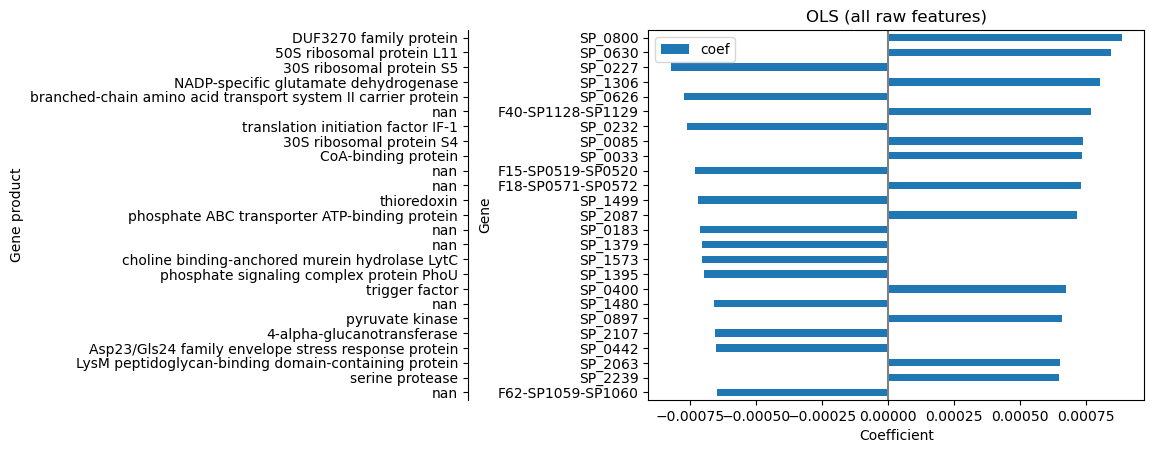

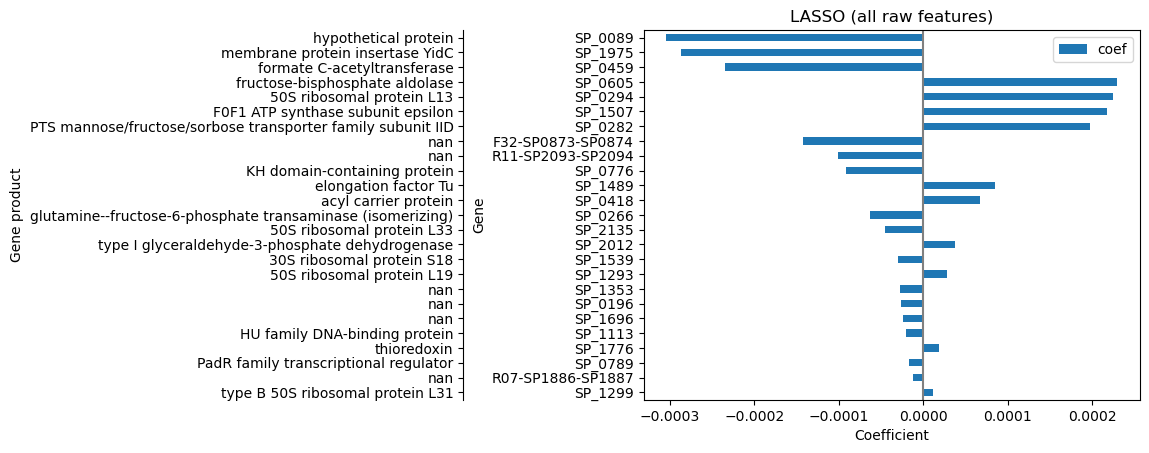

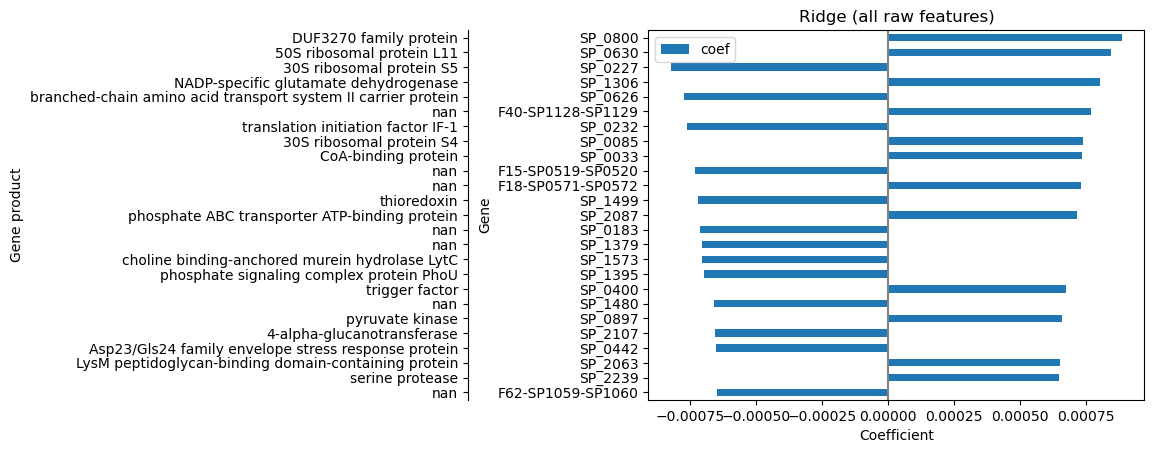

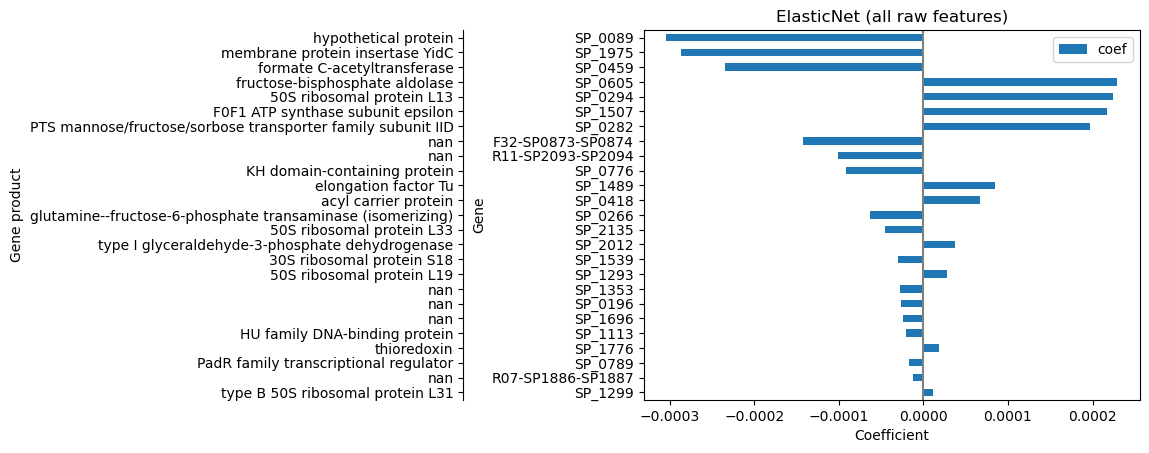

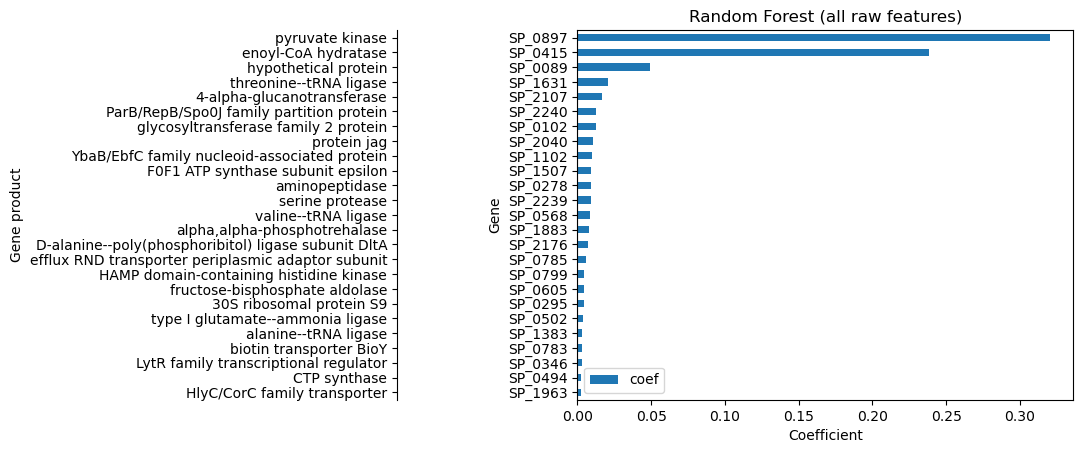

In [229]:
plot_coefs(feature_sort_reg(raw_lm, X_all_train), 25, annotations, "OLS (all raw features)")
plot_coefs(feature_sort_reg(raw_lasso, X_all_train), 25, annotations, "LASSO (all raw features)")
plot_coefs(feature_sort_reg(raw_ridge, X_all_train), 25, annotations, "Ridge (all raw features)")
plot_coefs(feature_sort_reg(raw_en, X_all_train), 25, annotations, "ElasticNet (all raw features)")
plot_coefs(feature_sort_tree(raw_rf, X_all_train), 25, annotations, "Random Forest (all raw features)")

### Attempt 2: Train on all log-transformed features

This time, we'll log transform all the features. We can replace any -inf with 0!

In [230]:
# Replace all 0s with 1 so that log will be 0 and not -inf
X_log_train = np.log(X_all_train.replace(0, 1))
X_log_test  = np.log(X_all_test.replace(0, 1))

# Check for any =inf values
print(X_log_train.isin([np.inf, -np.inf]).any().any())
print(X_log_test.isin([np.inf, -np.inf]).any().any())

False
False


Train and fit:

In [231]:
# Models
log_lm    = linear_model.LinearRegression()
log_lasso = linear_model.LassoCV(cv = 5)
log_ridge = linear_model.RidgeCV(cv = 5)
log_en    = linear_model.ElasticNetCV(cv = 5)
log_rf    = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)

# Fit
log_lm.fit(X_log_train, y_all_train)
log_lasso.fit(X_log_train, y_all_train)
log_ridge.fit(X_log_train, y_all_train)
log_en.fit(X_log_train, y_all_train)
log_rf.fit(X_log_train, y_all_train)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.646e-01, tolerance: 1.065e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklea

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Eval:

In [232]:
print(eval_table(title = "Models with all log-features",
           model_list = [log_lm, log_lasso, log_ridge, log_en, log_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_log_train, y_all_train, X_log_test, y_all_test]))

+------------------------------------------------------------+
|                Models with all log-features                |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.8665 | 0.6785 |     1.0     |   0.7594   |
|     LASSO     | 0.8266 | 0.6198 |    0.927    |   0.781    |
|     Ridge     | 0.8397 | 0.6447 |    0.9986   |   0.774    |
|   ElasticNet  | 0.8717 | 0.6288 |    0.9444   |   0.7565   |
| Random Forest | 0.999  | 0.6819 |    0.9851   |   0.6802   |
+---------------+--------+--------+-------------+------------+


Coefficient extraction:

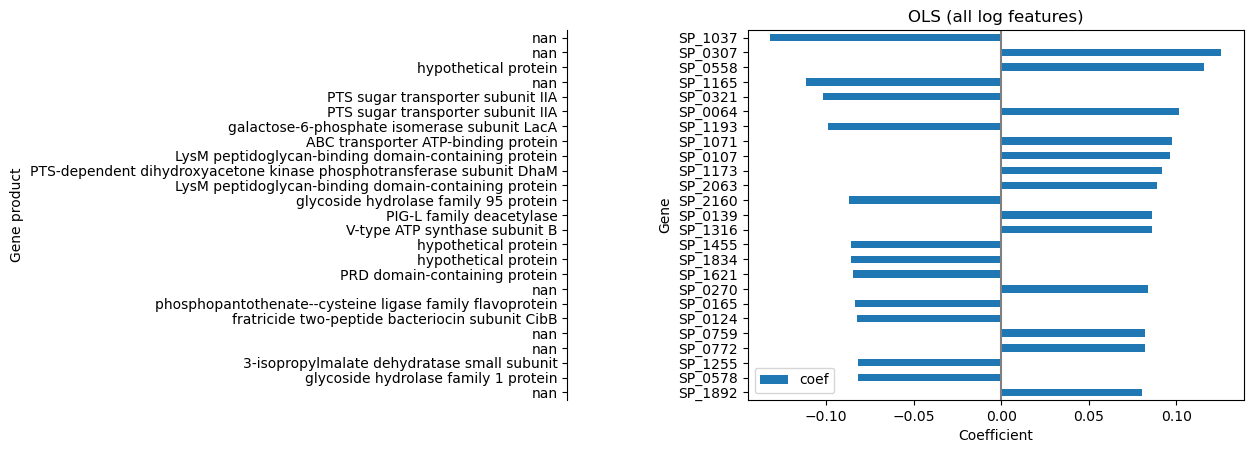

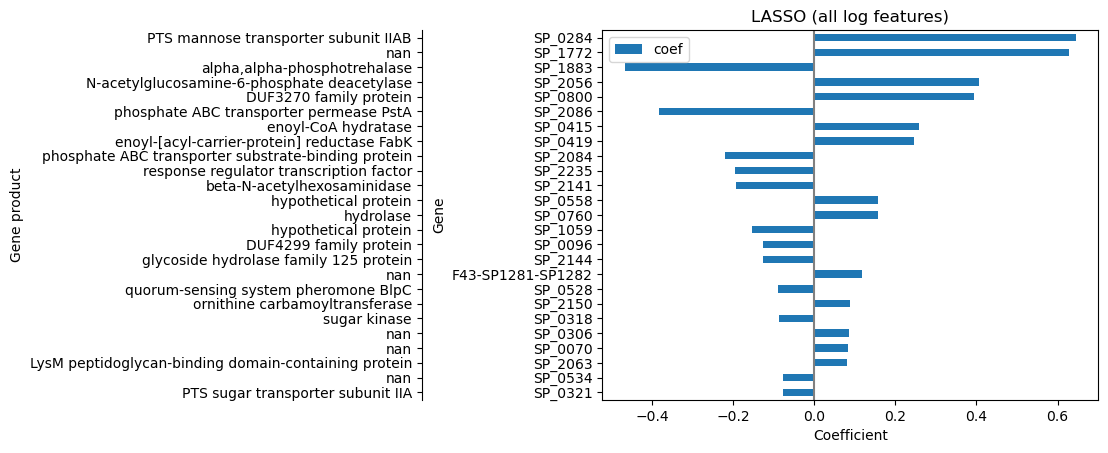

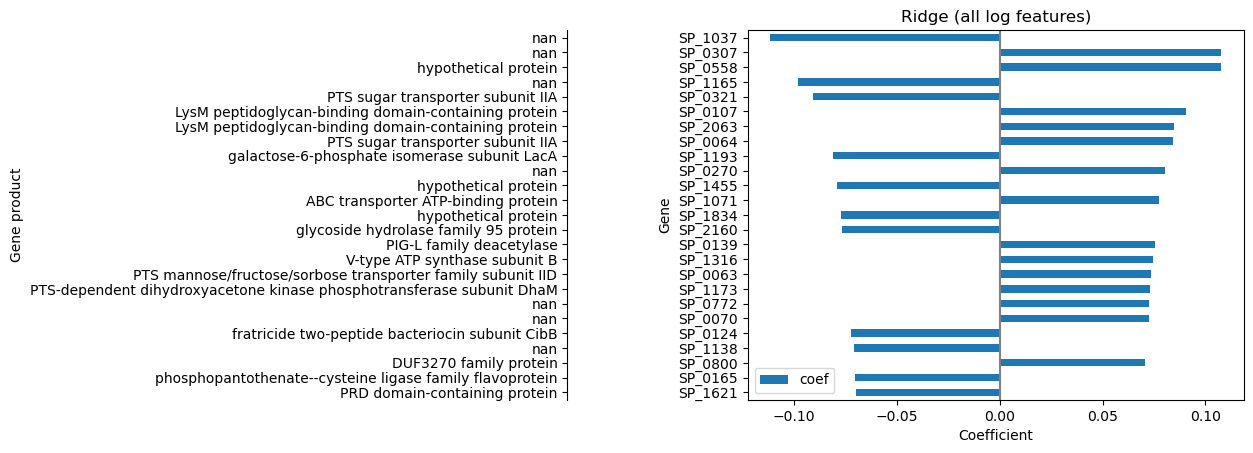

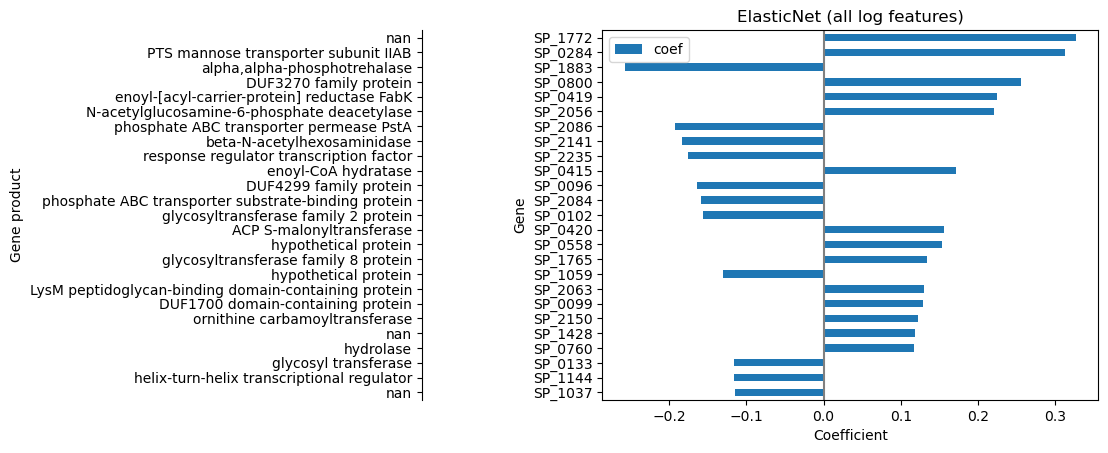

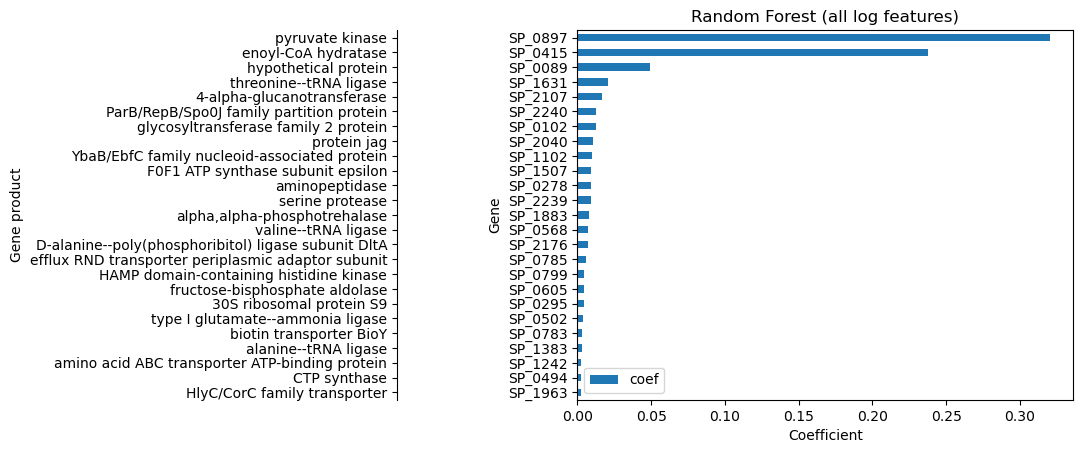

In [233]:
plot_coefs(feature_sort_reg(log_lm, X_log_train), 25, annotations, "OLS (all log features)")
plot_coefs(feature_sort_reg(log_lasso, X_log_train), 25, annotations, "LASSO (all log features)")
plot_coefs(feature_sort_reg(log_ridge, X_log_train), 25, annotations, "Ridge (all log features)")
plot_coefs(feature_sort_reg(log_en, X_log_train), 25, annotations, "ElasticNet (all log features)")
plot_coefs(feature_sort_tree(log_rf, X_log_train), 25, annotations, "Random Forest (all log features)")

### Attempt 3: Train on all standard-scaled features

This time, we'll try applying a standardscaler to all of our features. This will subtract all features by the the correpsonding mean and scale by the std.

In [234]:
from sklearn.preprocessing import StandardScaler

# Scalers for train and test data (separate so we don't have to resplit)
scaler1 = StandardScaler()

# Set output to preserve df
scaler1.set_output(transform = "pandas")

# Fit scalers
scaler1.fit(X_all_train)

# Transform data
X_scaled_train = scaler1.transform(X_all_train)
X_scaled_test  = scaler1.transform(X_all_test)

X_scaled_train

,SP_0001,SP_0002,SP_0003,SP_0004,SP_0005,SP_0006,SP_0007,SP_0008,SP_0009,SP_0010,...,SP_2230,SP_2231,SP_2233,SP_2234,SP_2235,SP_2236,SP_2237,SP_2238,SP_2239,SP_2240
Condition,,,,,,,,,,,,,,,,,,,,,
12AMX2hr-a,-1.012134,-0.832045,-0.530206,-0.400631,-0.616867,-0.213616,0.040940,-0.273010,0.051021,-0.314887,...,-0.811277,-0.748943,-0.442792,-1.051621,-0.983474,-0.862038,-0.379369,-0.628798,-1.235519,-1.310944
12AMX2hr-b,-1.081937,-0.916452,-0.697443,-0.375981,0.398222,-0.319903,0.578200,0.300181,-0.842459,-0.300437,...,-0.839947,-0.731335,-0.329097,-0.780473,-0.762308,-0.804225,-1.052122,-0.810395,-1.377807,-1.409970
12AMX2hr-c,-1.046824,-1.080235,-0.677382,-0.559396,-0.205425,-0.229665,0.683454,-0.410901,-0.008319,-0.460099,...,-0.912802,-0.790522,-0.887822,-0.547270,-0.806184,-0.807178,-0.569475,-0.016089,-1.382960,-1.468107
12CEF12CIP1hr-a,-0.188859,-0.608585,-0.392525,-0.566141,-0.201093,-0.419377,0.668907,-0.488966,1.068242,-0.501024,...,0.169564,-0.199829,-1.108125,-0.799429,0.146779,-0.342296,-0.269648,-0.514915,1.411536,-0.001283
12CEF12CIP1hr-b,-0.267593,-0.083908,0.237828,-0.639242,0.040637,-0.365260,-0.249760,-0.053322,-0.377527,-0.360999,...,0.357944,-0.138376,-0.265152,-0.529777,-0.144774,-0.635068,-1.052122,0.385261,1.459158,0.043491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34VNC2hr-b,-0.290795,-0.015210,-0.531306,-0.700483,-0.797539,-0.207806,-0.304299,-1.036839,-0.479072,-0.794110,...,-1.110600,-0.654723,-0.920208,-0.220853,-0.425949,-0.432984,-0.228734,-0.378504,-0.914727,-0.996912
34VNC2hr-c,-0.565770,-0.367794,-0.532674,-0.509231,-0.292892,-0.502928,-0.884457,-0.525908,-0.644464,-0.698339,...,-1.208320,-0.789492,-0.203694,-0.453434,-0.711607,-0.546526,0.080137,-0.954490,-0.943150,-0.953375
NDC4hr-a,-1.460004,-1.116219,-0.851839,-1.092458,-0.966377,-0.477589,-0.398095,-0.396382,-0.039748,-0.502000,...,-1.101263,-1.133400,-0.698592,-0.564616,-0.651257,-0.732950,-0.334349,0.371875,-0.303010,-0.336411


Train and fit. We'll also add in Bayesian regression and SV regression.

In [235]:
# Models
scaled_lm    = linear_model.LinearRegression()
scaled_lasso = linear_model.LassoCV(cv = 5)
scaled_ridge = linear_model.RidgeCV(cv = 5)
scaled_en    = linear_model.ElasticNetCV(cv = 5)
scaled_rf    = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)

# Fit
scaled_lm.fit(X_scaled_train, y_all_train)
scaled_lasso.fit(X_scaled_train, y_all_train)
scaled_ridge.fit(X_scaled_train, y_all_train)
scaled_en.fit(X_scaled_train, y_all_train)
scaled_rf.fit(X_scaled_train, y_all_train)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.133e-01, tolerance: 1.021e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklea

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Evaluate.

In [236]:
print(eval_table(title = "Models with all standard-scaled features",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train, y_all_train, X_scaled_test, y_all_test]))

+------------------------------------------------------------+
|          Models with all standard-scaled features          |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.8283 | 0.5959 |     1.0     |   0.7802   |
|     LASSO     | 0.8776 | 0.585  |    0.9728   |   0.7532   |
|     Ridge     | 0.821  | 0.5888 |    0.9999   |   0.784    |
|   ElasticNet  | 0.8736 | 0.5859 |    0.9808   |   0.7554   |
| Random Forest | 0.9977 | 0.6776 |    0.9851   |   0.681    |
+---------------+--------+--------+-------------+------------+


We're also interested in finding the performance metrics of the model only on certain data types. Let's try subsetting our data based on the condition name, so that we can see the R^2 on different drugs! 

In [ ]:
# Indices of each datatype in the train/test sets

# CIP
cip_index_train = [i for i in range(X_scaled_train.shape[0]) if "CIP" in X_scaled_train.iloc[i].name]
cip_index_test  = [i for i in range(X_scaled_test.shape[0]) if "CIP" in X_scaled_test.iloc[i].name]

# CEF
cef_index_train = [i for i in range(X_scaled_train.shape[0]) if "CEF" in X_scaled_train.iloc[i].name]
cef_index_test  = [i for i in range(X_scaled_test.shape[0]) if "CEF" in X_scaled_test.iloc[i].name]

# AMX
amx_index_train = [i for i in range(X_scaled_train.shape[0]) if "AMX" in X_scaled_train.iloc[i].name]
amx_index_test  = [i for i in range(X_scaled_test.shape[0]) if "AMX" in X_scaled_test.iloc[i].name]

# VNC
vnc_index_train = [i for i in range(X_scaled_train.shape[0]) if "VNC" in X_scaled_train.iloc[i].name]
vnc_index_test  = [i for i in range(X_scaled_test.shape[0]) if "VNC" in X_scaled_test.iloc[i].name]

Let's do the same for single vs. multiple drug data

In [238]:
# Single drug (check that there are 3 capital letters in the name)
single_index_train = [i for i in range(X_scaled_train.shape[0]) if sum(1 for char in X_scaled_train.iloc[i].name if char.isupper()) == 3]
single_index_test  = [i for i in range(X_scaled_test.shape[0]) if sum(1 for char in X_scaled_test.iloc[i].name if char.isupper()) == 3]

# Combination drug (check that there are 6 capital letters in the name)
combo_index_train = [i for i in range(X_scaled_train.shape[0]) if sum(1 for char in X_scaled_train.iloc[i].name if char.isupper()) == 6]
combo_index_test  = [i for i in range(X_scaled_test.shape[0]) if sum(1 for char in X_scaled_test.iloc[i].name if char.isupper()) == 6]


Model performance on CIP data:

In [255]:
tbl1 = eval_table(title = "Model performance on CIP data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[cip_index_train], y_all_train.iloc[cip_index_train], X_scaled_test.iloc[cip_index_test], y_all_test.iloc[cip_index_test]])
print(tbl1)

+------------------------------------------------------------+
|              Model performance on CIP data ()              |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.7059 | 0.5356 |     1.0     |   0.7422   |
|     LASSO     | 0.7002 | 0.4992 |    0.9583   |   0.7463   |
|     Ridge     | 0.701  | 0.5296 |    0.9998   |   0.7457   |
|   ElasticNet  | 0.7093 | 0.4979 |    0.9708   |   0.7397   |
| Random Forest | 0.9282 | 0.6223 |    0.9799   |   0.5542   |
+---------------+--------+--------+-------------+------------+


Model performance on CEF data:

In [256]:
tbl2 = eval_table(title = "Model performance on CEF data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[cef_index_train], y_all_train.iloc[cef_index_train], X_scaled_test.iloc[cef_index_test], y_all_test.iloc[cef_index_test]])
print(tbl2)

+------------------------------------------------------------+
|              Model performance on CEF data ()              |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.9823 | 0.7478 |     1.0     |   0.681    |
|     LASSO     | 0.9926 | 0.7132 |    0.9613   |   0.6743   |
|     Ridge     | 0.9663 | 0.7339 |    0.9998   |   0.6913   |
|   ElasticNet  | 0.9816 | 0.7037 |    0.9724   |   0.6815   |
| Random Forest | 0.9287 | 0.739  |    0.9779   |   0.7149   |
+---------------+--------+--------+-------------+------------+


Model performance on AMX data:

In [258]:
tbl3 = eval_table(title = "Model performance on AMX data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[amx_index_train], y_all_train.iloc[amx_index_train], X_scaled_test.iloc[amx_index_test], y_all_test.iloc[amx_index_test]])
print(tbl3)

+------------------------------------------------------------+
|              Model performance on AMX data ()              |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.6041 | 0.5167 |     1.0     |   0.7225   |
|     LASSO     | 0.594  | 0.5206 |    0.9241   |   0.7317   |
|     Ridge     | 0.5986 | 0.5167 |    0.9995   |   0.7275   |
|   ElasticNet  | 0.5868 | 0.5257 |    0.9418   |   0.7382   |
| Random Forest | 0.3888 | 0.2687 |    0.965    |   0.885    |
+---------------+--------+--------+-------------+------------+


Model performance on VNC data:

In [259]:
tbl4 = eval_table(title = "Model performance on VNC data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[vnc_index_train], y_all_train.iloc[vnc_index_train], X_scaled_test.iloc[vnc_index_test], y_all_test.iloc[vnc_index_test]])
print(tbl4)

+------------------------------------------------------------+
|              Model performance on VNC data ()              |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.654  | 0.4617 |     1.0     |   0.7415   |
|     LASSO     | 0.6107 | 0.4116 |    0.9631   |   0.7746   |
|     Ridge     | 0.6502 | 0.4567 |    0.9998   |   0.7445   |
|   ElasticNet  | 0.6392 | 0.4236 |    0.9749   |   0.753    |
| Random Forest | 0.5702 | 0.4055 |    0.9819   |   0.8035   |
+---------------+--------+--------+-------------+------------+


Model performance on single-drug data:

In [261]:
tbl5 = eval_table(title = "Model performance on single-drug data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[single_index_train], y_all_train.iloc[single_index_train], X_scaled_test.iloc[single_index_test], y_all_test.iloc[single_index_test]])
print(tbl5)

+------------------------------------------------------------+
|          Model performance on single-drug data ()          |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.9683 | 0.6885 |     1.0     |   0.7831   |
|     LASSO     | 1.0902 | 0.7266 |    0.9676   |   0.7251   |
|     Ridge     | 0.9594 |  0.68  |    0.9998   |   0.7871   |
|   ElasticNet  | 1.0746 | 0.7342 |    0.977    |   0.7329   |
| Random Forest | 1.3296 | 0.9496 |    0.9748   |   0.5911   |
+---------------+--------+--------+-------------+------------+


Model performance on multiple-drug data:

In [262]:
tbl6 = eval_table(title = "Model performance on combination data ()",
           model_list = [scaled_lm, scaled_lasso, scaled_ridge, scaled_en, scaled_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_scaled_train.iloc[combo_index_train], y_all_train.iloc[combo_index_train], X_scaled_test.iloc[combo_index_test], y_all_test.iloc[combo_index_test]])
print(tbl6)

+------------------------------------------------------------+
|          Model performance on combination data ()          |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.7219 | 0.5353 |     1.0     |   0.7142   |
|     LASSO     | 0.7043 | 0.4922 |    0.9501   |   0.728    |
|     Ridge     | 0.716  | 0.5291 |    0.9998   |   0.7189   |
|   ElasticNet  | 0.7118 | 0.4888 |    0.9651   |   0.7221   |
| Random Forest | 0.6996 | 0.4993 |    0.9782   |   0.7316   |
+---------------+--------+--------+-------------+------------+


Let's plot the R^2 (train) of each model for each data type. The R^2(test) are all essentially the same.

In [280]:
# Store r^2
r2s = [row[4] for row in tbl1.rows] + [row[4] for row in tbl2.rows] + [row[4] for row in tbl3.rows] + [row[4] for row in tbl4.rows] + [row[4] for row in tbl5.rows] + [row[4] for row in tbl6.rows]

datatypes = ["CIP"]*5 + ["CEF"]*5 + ["AMX"]*5 + ["VNC"]*5 + ["Single-drug"]*5 + ["Multi-drug"]*5

# Construct dataframe of R^2 (train) for each model
evals = {
    "Model": ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"]*6,
    "Datatype": datatypes,
    "R^2 (test)": r2s
}

# DF
evals = pd.DataFrame(evals)

Text(0.5, 1.0, 'Models trained using standard-scaled features')

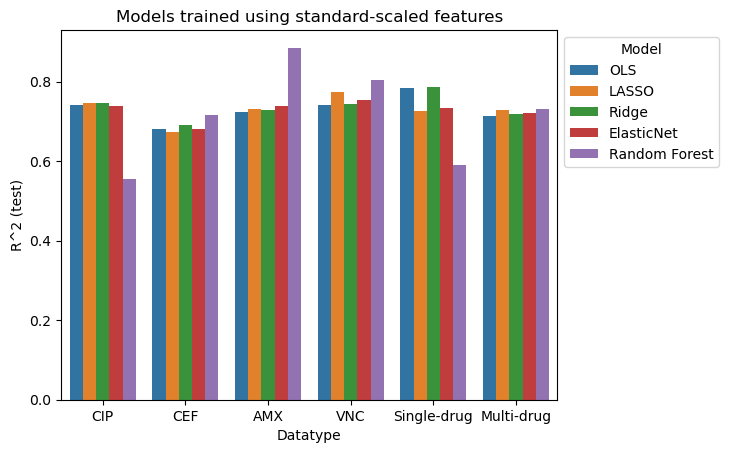

In [287]:
ax = sns.barplot(data = evals, x = "Datatype", y = "R^2 (test)", hue = "Model")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title("Models trained using standard-scaled features")

Stable performance across classes

Coefficient extraction:

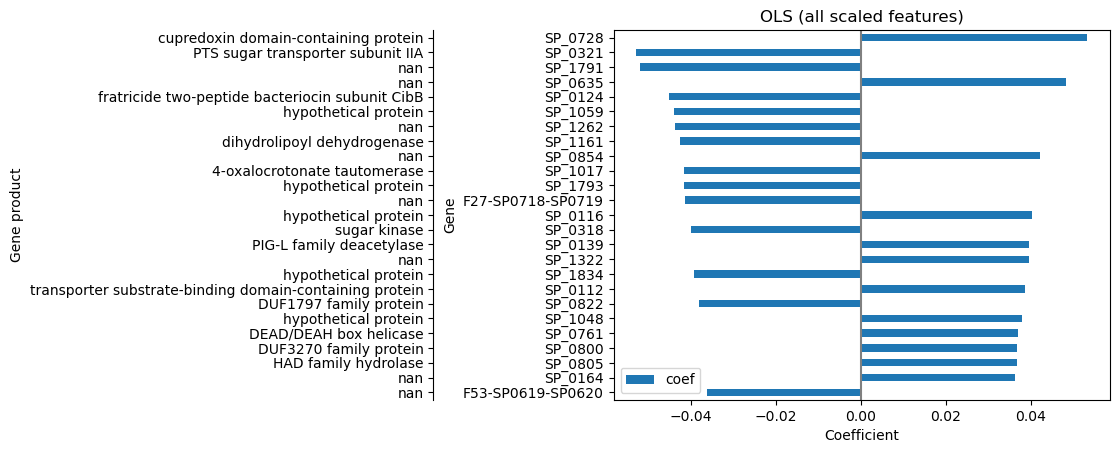

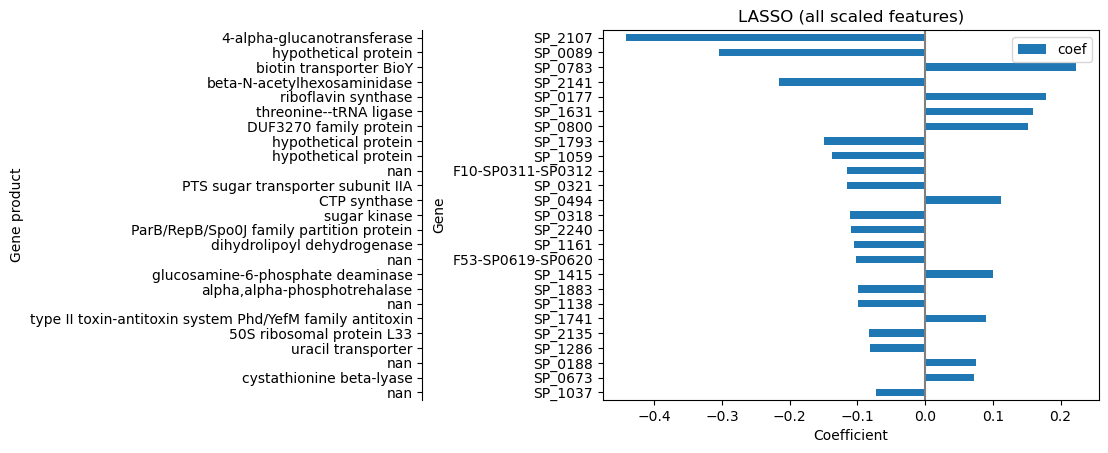

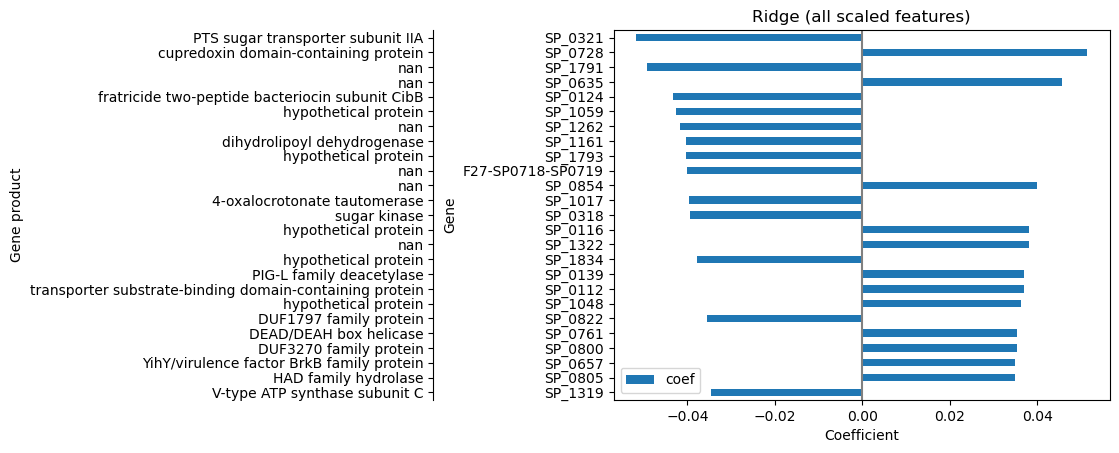

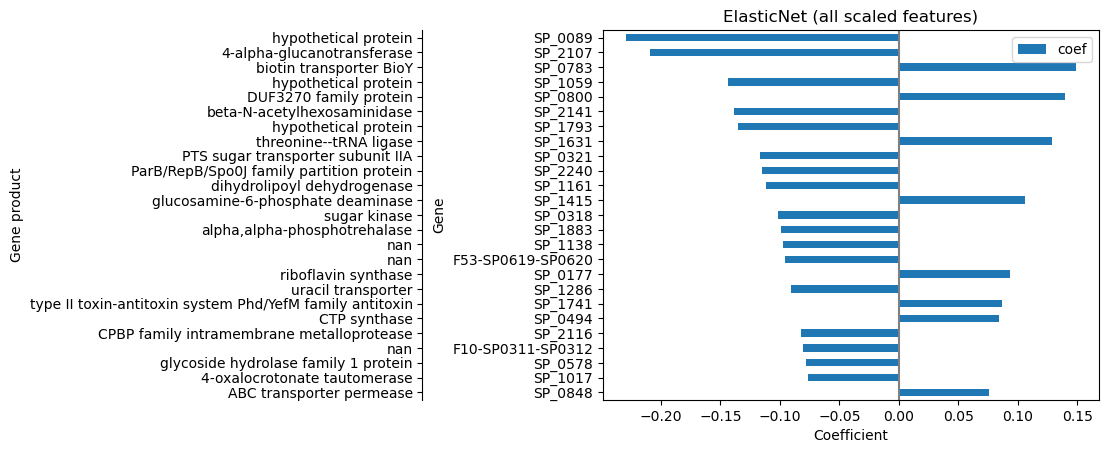

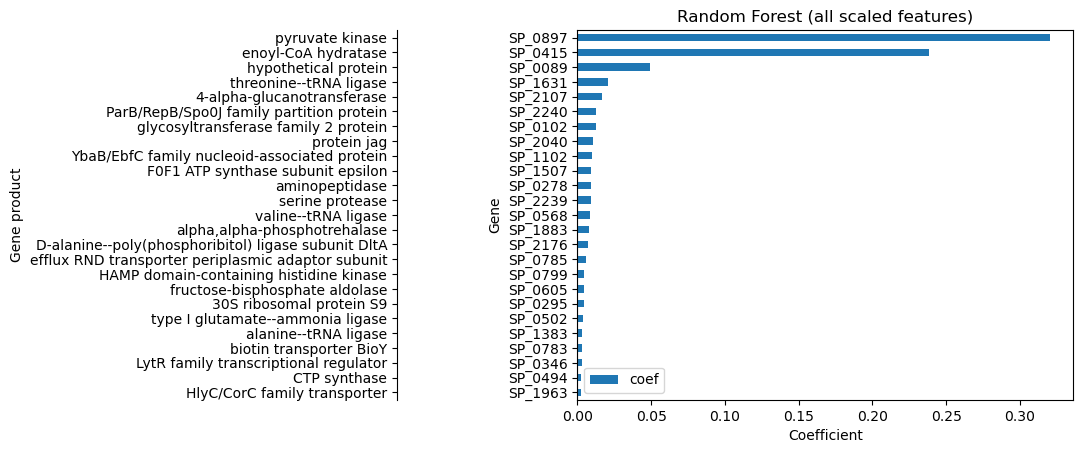

In [245]:
plot_coefs(feature_sort_reg(scaled_lm, X_scaled_train), 25, annotations, "OLS (all scaled features)")
plot_coefs(feature_sort_reg(scaled_lasso, X_scaled_train), 25, annotations, "LASSO (all scaled features)")
plot_coefs(feature_sort_reg(scaled_ridge, X_scaled_train), 25, annotations, "Ridge (all scaled features)")
plot_coefs(feature_sort_reg(scaled_en, X_scaled_train), 25, annotations, "ElasticNet (all scaled features)")
plot_coefs(feature_sort_tree(scaled_rf, X_scaled_train), 25, annotations, "Random Forest (all scaled features)")

### Attempt 4: Train on all scaled features with tree-based filtering (BAD)

We'll try applying an extratrees regression to select our top features before we run our models.

In [246]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectFromModel

# Fit ExtraTrees Regressor to select top features
clf = ExtraTreesRegressor(n_estimators = 100, random_state = 111)
clf = clf.fit(X_scaled_train, y_all_train)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Select top features.

In [247]:
# Define selector to select top features from extratrees regressor
selector = SelectFromModel(clf, prefit = True)

# Keep data as df
selector.set_output(transform = "pandas")

# Subset data to appropriate features
X_train_tree = selector.transform(X_scaled_train)
X_test_tree = selector.transform(X_scaled_test)

# Check dims
print(f"ExtraTrees Regressor selected {X_train_tree.shape[1]} features")

ExtraTrees Regressor selected 200 features


c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Train

In [248]:
# Models
tree_lm = linear_model.LinearRegression()
tree_lasso = linear_model.LassoCV(cv = 5)
tree_ridge = linear_model.RidgeCV(cv = 5)
tree_en = linear_model.ElasticNetCV(cv = 5)
tree_rf = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)

# Train
tree_lm.fit(X_train_tree, y_all_train)
tree_lasso.fit(X_train_tree, y_all_train)
tree_ridge.fit(X_train_tree, y_all_train)
tree_en.fit(X_train_tree, y_all_train)
tree_rf.fit(X_train_tree, y_all_train)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.105e-01, tolerance: 1.080e-01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.324e-01, tolerance: 1.080e-01
  model = cd_fast.enet_co

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Eval

In [249]:
print(eval_table(title = "Models with all standard-scaled features",
           model_list = [tree_lm, tree_lasso, tree_ridge, tree_en, tree_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_train_tree, y_all_train, X_test_tree, y_all_test]))

+------------------------------------------------------------+
|          Models with all standard-scaled features          |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 0.9455 | 0.7456 |    0.9792   |   0.7135   |
|     LASSO     | 0.7531 | 0.5421 |    0.9427   |   0.8183   |
|     Ridge     | 0.7759 | 0.5823 |    0.9602   |   0.8071   |
|   ElasticNet  | 0.7521 | 0.539  |    0.9392   |   0.8187   |
| Random Forest | 0.9583 | 0.6315 |    0.9881   |   0.7057   |
+---------------+--------+--------+-------------+------------+


Train models

## Model type 3: Use single-drug data to predict multi-drug data

### Attempt 1: Train on all standard-scaled features

We've seen that standard scaling seems to perform the best. We'll continue with log-CFUs as well. We'll split the groups by hand this time.

In [250]:
# Indices of samples with 1 or multi drug
single_drug_index = [i for i in range(X_all.shape[0]) if sum(1 for char in X_all.iloc[i].name if char.isupper()) == 3]
multi_drug_index  = [i for i in range(X_all.shape[0]) if sum(1 for char in X_all.iloc[i].name if char.isupper()) == 6]

# Train/test split
X_sing_train, y_sing_train = X_all.iloc[single_drug_index], y_all.iloc[single_drug_index]
X_sing_test, y_sing_test   = X_all.iloc[multi_drug_index], y_all.iloc[multi_drug_index]

# Scaler object
scaler2 = StandardScaler()

# Set output to preserve df
scaler2.set_output(transform = "pandas")

# Fit scaler on training data
scaler2.fit(X_sing_train)

# Transform data
X_sing_train = scaler2.transform(X_sing_train)

# Check dims
print(f" Training data dims : {X_sing_train.shape}")
print(f" Test data dims     : {X_sing_test.shape} ")

 Training data dims : (182, 2191)
 Test data dims     : (288, 2191) 


We see that our test set is much larger than the training set. Let's try subsetting our test data to a random set of 120, which would gives 2:1 train/test ratio. We'll construct several random sets of 120.

In [251]:
from sklearn.model_selection import train_test_split

# Use train_test_split, then just select the first output
X_sing_test1, y_sing_test1 = train_test_split(X_sing_test, y_sing_test, test_size = (288-120) / 288, random_state = 111)[0:3:2]
X_sing_test2, y_sing_test2 = train_test_split(X_sing_test, y_sing_test, test_size = (288-120) / 288, random_state = 112)[0:3:2]
X_sing_test3, y_sing_test3 = train_test_split(X_sing_test, y_sing_test, test_size = (288-120) / 288, random_state = 113)[0:3:2]
X_sing_test4, y_sing_test4 = train_test_split(X_sing_test, y_sing_test, test_size = (288-120) / 288, random_state = 114)[0:3:2]

# Scale each one of the Xs
X_sing_test1 = scaler2.transform(X_sing_test1)
X_sing_test2 = scaler2.transform(X_sing_test2)
X_sing_test3 = scaler2.transform(X_sing_test3)
X_sing_test4 = scaler2.transform(X_sing_test4)

In [252]:
print(f"dim of new test : {X_sing_test1.shape}")

dim of new test : (120, 2191)


In [253]:
# Models for split 1
sing_lm    = linear_model.LinearRegression()
sing_lasso = linear_model.LassoCV(cv = 5)
sing_ridge = linear_model.RidgeCV(cv = 5)
sing_en    = linear_model.ElasticNetCV(cv = 5)
sing_rf    = ensemble.RandomForestRegressor(n_estimators = 100, random_state = 111)

sing_lm.fit(X_sing_train, y_sing_train)
sing_lasso.fit(X_sing_train, y_sing_train)
sing_ridge.fit(X_sing_train, y_sing_train)
sing_en.fit(X_sing_train, y_sing_train)
sing_rf.fit(X_sing_train, y_sing_train)

c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\eddyk\miniconda3\envs\ml\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Evals

In [254]:
print(eval_table(title = "Split 1",
           model_list = [sing_lm, sing_lasso, sing_ridge, sing_en, sing_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_sing_train, y_sing_train, X_sing_test1, y_sing_test1]))
print(eval_table(title = "Split 2",
           model_list = [sing_lm, sing_lasso, sing_ridge, sing_en, sing_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_sing_train, y_sing_train, X_sing_test2, y_sing_test2]))
print(eval_table(title = "Split 3",
           model_list = [sing_lm, sing_lasso, sing_ridge, sing_en, sing_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_sing_train, y_sing_train, X_sing_test3, y_sing_test3]))
print(eval_table(title = "Split 4",
           model_list = [sing_lm, sing_lasso, sing_ridge, sing_en, sing_rf],
           name_list = ["OLS", "LASSO", "Ridge", "ElasticNet", "Random Forest"],
           data = [X_sing_train, y_sing_train, X_sing_test4, y_sing_test4]))

+------------------------------------------------------------+
|                          Split 1                           |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------------+
|      OLS      | 1.626  | 1.345  |     1.0     |   0.0422   |
|     LASSO     | 1.6223 | 1.3562 |    0.971    |   0.0466   |
|     Ridge     | 1.6241 | 1.3416 |    0.9999   |   0.0444   |
|   ElasticNet  | 1.634  | 1.3612 |    0.968    |   0.0328   |
| Random Forest | 1.8958 | 1.5194 |    0.984    |   -0.302   |
+---------------+--------+--------+-------------+------------+
+------------------------------------------------------------+
|                          Split 2                           |
+---------------+--------+--------+-------------+------------+
|     Model     |  RMSE  |  MAE   | R^2 (Train) | R^2 (Test) |
+---------------+--------+--------+-------------+------

VERY BAD generalization to multi-drug data, this is not a good sign....

## Model type 4: Use 1hr data to predict 2/4hr data